# 1- **Setup Inicial**

In [1]:
import time
import random
import itertools
import numpy as np
import matplotlib.pyplot as plt

# 2- **Motivación: Planning + IA**

In [5]:
# Problema simple de rutas (tipo TSP reducido)
## analiza todas las opciones (matriz), y se queda con todas la combinaciones de menor

n = 5
dist = np.random.randint(1, 20, (n, n))

def costo_ruta(ruta):
    return sum(dist[ruta[i]][ruta[i+1]] for i in range(len(ruta)-1))

mejor_costo = float('inf')
mejor = None

for perm in itertools.permutations(range(n)): # ver itertools
    c = costo_ruta(perm)
    if c < mejor_costo:
        mejor_costo = c
        mejor = perm

print("Mejor ruta:", mejor)
print("Costo de la mejor ruta:", mejor_costo)

Mejor ruta: (2, 4, 0, 1, 3)
Costo de la mejor ruta: 13


In [8]:
dist
# cada fila representa un nodo, y cada columna el peso del recorrido desde cada nodo a otro.

array([[11,  1, 19, 12, 18],
       [17, 16,  5,  6, 18],
       [ 5, 10, 10, 11,  1],
       [13,  4,  9, 12,  6],
       [ 5, 10,  1, 13,  4]])

**Discusión**:

* ¿Escala?
* ¿Qué pasa si n = 15?

# 3- **Algoritmos y eficiencia**

In [9]:
def busqueda_lineal(lista, x):
    for i, v in enumerate(lista):
        if v == x:
            return i
    return -1

def busqueda_binaria(lista, x):
    low, high = 0, len(lista)-1
    while low <= high:
        mid = (low + high)//2
        if lista[mid] == x:
            return mid
        elif lista[mid] < x:
            low = mid + 1
        else:
            high = mid - 1
    return -1

## Experimento

In [10]:
lista = sorted(random.sample(range(1000000), 100000))

start = time.time()
busqueda_lineal(lista, lista[-1])
print("Lineal:", time.time()-start)

start = time.time()
busqueda_binaria(lista, lista[-1])
print("Binaria:", time.time()-start)

Lineal: 0.010726690292358398
Binaria: 0.0001277923583984375


# 4- **Computabilidad**

In [12]:
def posible_loop(x):
    while x > 0:
        x = x - 1

¿Podemos detectar automáticamente si un programa entra en loop?

Introducir:

* Problema de parada
* No decidibilidad

# 5- **Complejidad: explosión combinatoria**

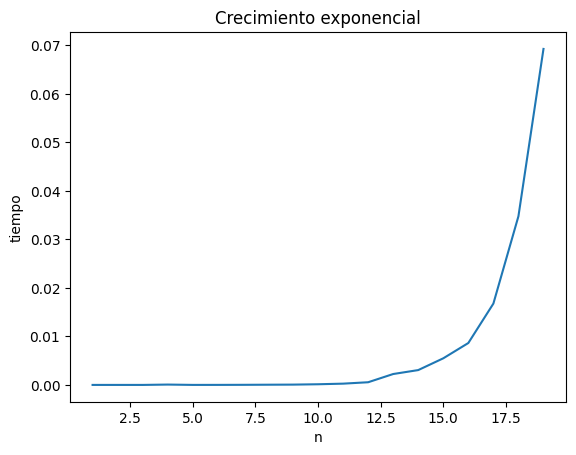

In [13]:
# El comportamiento del algoritmo (problema) es independiente de la tecnología (procesador, etc)
# -

def exponencial(n):
    if n == 0:
        return 1
    return exponencial(n-1) + exponencial(n-1)

tiempos = []
valores = range(1, 20)

for i in valores:
    start = time.time()
    exponencial(i)
    tiempos.append(time.time() - start)

plt.plot(valores, tiempos)
plt.xlabel("n")
plt.ylabel("tiempo")
plt.title("Crecimiento exponencial")
plt.show()

**Discusión**:

* P vs NP
* Por qué NP-completo es importante

# 6. **Heurísticas (clave en IA)**

In [16]:
# La herística hace referencia a los pasos decididos a seguir para resolver el problema (?)

def greedy_ruta(dist, inicio=0):
    visitados = [inicio]
    actual = inicio

    while len(visitados) < len(dist):
        siguiente = min(
            (n for n in range(len(dist)) if n not in visitados),
            key=lambda x: dist[actual][x]
        )
        visitados.append(siguiente)
        actual = siguiente

    return visitados

Comparar

In [15]:
print("Greedy:", greedy_ruta(dist))

Greedy: [0, 1, 2, 4, 3]


# 7. **Conclusión**
- Muchos problemas de planning son NP-completos
- No siempre podemos resolver óptimamente
- IA usa heurísticas y aproximaciones
